# Custom State 활용

## 환경 변수 로드

In [12]:
from dotenv import load_dotenv

load_dotenv()

OPENAI_LLM_MODEL = 'gpt-4.1-mini'

## 카카오 장소 검색 함수

In [13]:
import os
import requests
from typing import Any

def kakao_search_place(query: str, size: int = 5) -> list[dict[str, Any]]:
    """카카오 장소 검색 API를 호출하고 수업에서 사용할 필드만 정리해 반환한다."""

    api_key = os.getenv("KAKAO_API_KEY")
    if not api_key:
        raise RuntimeError("KAKAO_API_KEY가 설정되어 있지 않습니다.")

    url = "https://dapi.kakao.com/v2/local/search/keyword.json"
    headers = {
        "Authorization": f"KakaoAK {api_key}",
    }
    params = {
        "query": query,
        "size": size,
    }

    response = requests.get(url, headers=headers, params=params, timeout=10)
    response.raise_for_status()

    places = response.json().get("documents", [])

    # API 응답 전체를 그대로 State에 넣으면 불필요한 정보가 많다.
    # 수업에서는 답변 생성에 필요한 값만 선별해 저장한다.
    return [
        {
            "name": place.get("place_name", ""),
            "category": place.get("category_name", ""),
            "address": place.get("address_name", ""),
            "road_address": place.get("road_address_name", ""),
            "phone": place.get("phone", ""),
            "url": place.get("place_url", ""),
        }
        for place in places
    ]

## 카카오 장소 검색 함수 테스트

In [14]:
from pprint import pprint

try:
    pprint(kakao_search_place('신대방삼거리 돈까스',size=3))
except Exception as e:
    print('카카오 API 테스트 실패:',e)

[{'address': '서울 동작구 신대방동 344-15',
  'category': '음식점 > 일식 > 돈까스,우동',
  'name': '모스키친',
  'phone': '02-6497-3529',
  'road_address': '서울 동작구 보라매로 91',
  'url': 'http://place.map.kakao.com/1448531833'},
 {'address': '서울 동작구 상도동 322-17',
  'category': '음식점 > 일식 > 돈까스,우동 > 역전우동0410',
  'name': '역전우동0410 신대방삼거리역점',
  'phone': '02-825-5066',
  'road_address': '서울 동작구 국사봉1길 28',
  'url': 'http://place.map.kakao.com/971652158'},
 {'address': '서울 동작구 상도동 323-27',
  'category': '음식점 > 일식',
  'name': '카츠 디나인 신대방삼거리 본점',
  'phone': '010-2163-4150',
  'road_address': '서울 동작구 국사봉1길 12-5',
  'url': 'http://place.map.kakao.com/1548241074'}]


## Custom state 정의

In [15]:
from typing import Annotated, Optional, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class KakaoPlace(TypedDict,total=False):
    """카카오 장소 검색 결과 중 사용할 필드만 정리"""
    name:str
    category:str
    address:str
    road_address:str
    phone:str
    url:str

class State(TypedDict, total=False):
    """그래프 전체에서 공유할 작업 상태
    total=False로 정의했으므로 초기 입력에서 모든 필드를 넣지 않아도 된다.
    """

    messages:Annotated[list[AnyMessage],add_messages]

    search_query:Optional[str]
    search_results:Optional[list[KakaoPlace]]
    answer:Optional[str]
    error:Optional[str]

## LLM 준비
하나의 모델을 두 가지 용도로 사용한다.
- 사용자 요청에서 검색 키워드를 구조화해서 추출
- 검색 결과를 바탕으로 최종 답변 생성

In [16]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=OPENAI_LLM_MODEL,temperature=0)

class SearchQuery(BaseModel):
    """장소 검색 API에 전달할 검색어 스키마"""
    query:str = Field(
        description=(
            "카카오 장소 검색 API에 전달한 명확한 검색어"
            "장소명, 지역명, 음식 종류, 업종을 중심으로 작성한다."
        )
    )

query_extractor = llm.with_structured_output(SearchQuery)

## 노드 함수 정의
- extract_search_query : 사용자 메세지에서 장소 검색어 추출
- search_place : 검색어로 카카오 검색 API 호출
- generate_answer : 검색 결과를 사용자에게 읽기 좋은 답변으로 정리

In [17]:
import json
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage


def get_last_human_message(state: State) -> str:
    """State의 messages에서 마지막 사용자 메시지 내용을 찾는다."""

    for message in reversed(state.get("messages", [])):
        if isinstance(message, HumanMessage):
            return message.content

        # add_messages reducer를 사용하면 dict 입력도 Message 객체로 변환되는 것이 일반적이지만,
        # 수업 중 다양한 입력 형식을 다룰 수 있으므로 dict 형태도 함께 처리한다.
        if isinstance(message, dict) and message.get("role") in {"user", "human"}:
            return message.get("content", "")

    return ""


def extract_search_query(state: State) -> dict:
    """사용자 자연어 요청에서 장소 검색 API에 전달할 검색어를 추출한다."""

    user_request = get_last_human_message(state)

    result = query_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "너는 장소 검색어를 만드는 도우미이다. "
                    "사용자의 자연어 요청에서 카카오 장소 검색 API에 넣기 좋은 검색어만 추출한다. "
                    "검색어는 너무 길게 만들지 말고, 지역명과 핵심 업종/음식명을 중심으로 만든다."
                )
            ),
            HumanMessage(content=user_request),
        ]
    )

    # search_query는 reducer가 없으므로 최신 값으로 덮어써진다.
    return {"search_query": result.query}


def search_places(state: State) -> dict:
    """State에 저장된 search_query를 사용해 장소 검색을 수행한다."""

    query = state.get("search_query")
    if not query:
        return {
            "search_results": [],
            "error": "검색어를 추출하지 못했습니다.",
        }

    try:
        results = kakao_search_place(query, size=5)
        return {
            "search_results": results,
            "error": None,
        }
    except Exception as e:
        # 외부 API 실패도 State에 저장해 두면 다음 노드에서 사용자에게 안내할 수 있다.
        return {
            "search_results": [],
            "error": str(e),
        }


def generate_answer(state: State) -> dict:
    """검색 결과를 바탕으로 사용자에게 보여줄 최종 답변을 생성한다."""

    user_request = get_last_human_message(state)
    search_query = state.get("search_query")
    search_results = state.get("search_results") or []
    error = state.get("error")

    if error:
        answer = (
            "장소 검색을 진행하는 중 문제가 발생했습니다.\n\n"
            f"오류 내용: {error}\n\n"
            "API 키 설정이나 네트워크 상태를 확인해 주세요."
        )
        return {
            "answer": answer,
            "messages": [AIMessage(content=answer)],
        }

    if not search_results:
        answer = (
            f"'{search_query}' 검색어로 찾은 장소가 없습니다. "
            "지역명이나 음식 종류를 조금 더 구체적으로 바꿔서 다시 요청해 주세요."
        )
        return {
            "answer": answer,
            "messages": [AIMessage(content=answer)],
        }

    places_json = json.dumps(search_results, ensure_ascii=False, indent=2)

    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "너는 장소 검색 결과를 사용자에게 보기 좋게 정리하는 도우미이다. "
                    "반드시 제공된 검색 결과 안의 정보만 사용한다. "
                    "검색 결과에 없는 평점, 리뷰 수, 영업시간, 메뉴 가격은 추측하지 않는다. "
                    "장소명, 주소, 전화번호, 링크를 중심으로 간단히 추천한다."
                )
            ),
            HumanMessage(
                content=(
                    f"사용자 요청:\n{user_request}\n\n"
                    f"추출된 검색어:\n{search_query}\n\n"
                    f"검색 결과 JSON:\n{places_json}\n\n"
                    "위 검색 결과를 바탕으로 한국어로 답변해줘."
                )
            ),
        ]
    )

    return {
        "answer": response.content,
        "messages": [response],
    }

## 그래프 구성

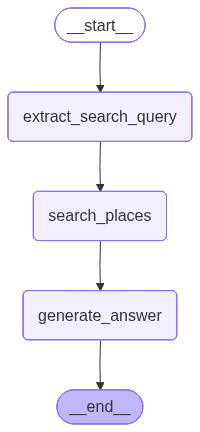

In [18]:
from langgraph.graph import START,END,StateGraph

def build_graph():
    workflow = StateGraph(State)

    workflow.add_node('extract_search_query', extract_search_query)
    workflow.add_node('search_places', search_places)
    workflow.add_node('generate_answer', generate_answer)

    workflow.add_edge(START,'extract_search_query')
    workflow.add_edge('extract_search_query','search_places')
    workflow.add_edge('search_places','generate_answer')
    workflow.add_edge('generate_answer',END)

    return workflow.compile()  

graph = build_graph()
graph     

## 장소 검색 챗봇 실행

In [19]:
from IPython.display import Markdown

initial_state = {
    'messages' : [
        HumanMessage(content='신대방 삼거리역 근처의 돈까스 맛있는 집 찾아줘, 배고파.')
    ]
}

final_state = graph.invoke(initial_state)

Markdown(final_state['messages'][-1].content)

신대방삼거리역 근처에서 돈까스 맛있게 즐길 수 있는 곳을 추천해드릴게요.

1. 모스키친  
- 주소: 서울 동작구 보라매로 91 (신대방동 344-15)  
- 전화: 02-6497-3529  
- 특징: 돈까스와 우동을 함께 즐길 수 있는 일식집입니다.  
- 상세보기: [모스키친 바로가기](http://place.map.kakao.com/1448531833)

2. 카츠 디나인 신대방삼거리 본점  
- 주소: 서울 동작구 국사봉1길 12-5 (상도동 323-27)  
- 전화: 010-2163-4150  
- 특징: 일식 돈까스 전문점입니다.  
- 상세보기: [카츠 디나인 바로가기](http://place.map.kakao.com/1548241074)

3. 돈까스짱 상도동점  
- 주소: 서울 동작구 성대로 14 (상도동 316-2)  
- 전화: 02-813-8887  
- 상세보기: [돈까스짱 바로가기](http://place.map.kakao.com/615937349)

4. 정성카츠 신대방삼거리점  
- 주소: 서울 동작구 여의대방로22길 121 (신대방동 724)  
- 전화: 0507-1350-3471  
- 상세보기: [정성카츠 바로가기](http://place.map.kakao.com/1104790629)

배고플 때 맛있는 돈까스 드시고 힘내세요!

## 최종 State 확인

In [22]:
print("검색어 :", final_state.get('search_query'))
print("검색 결과 개수 :", len(final_state.get('search_results')))
print('오류 : ', final_state.get('error'))
print('최종 답변 저장 여부 :', bool(final_state.get('answer')))

pprint(final_state.get('search_results'))

검색어 : 신대방삼거리역 돈까스
검색 결과 개수 : 5
오류 :  None
최종 답변 저장 여부 : True
[{'address': '서울 동작구 신대방동 344-15',
  'category': '음식점 > 일식 > 돈까스,우동',
  'name': '모스키친',
  'phone': '02-6497-3529',
  'road_address': '서울 동작구 보라매로 91',
  'url': 'http://place.map.kakao.com/1448531833'},
 {'address': '서울 동작구 상도동 322-17',
  'category': '음식점 > 일식 > 돈까스,우동 > 역전우동0410',
  'name': '역전우동0410 신대방삼거리역점',
  'phone': '02-825-5066',
  'road_address': '서울 동작구 국사봉1길 28',
  'url': 'http://place.map.kakao.com/971652158'},
 {'address': '서울 동작구 상도동 323-27',
  'category': '음식점 > 일식',
  'name': '카츠 디나인 신대방삼거리 본점',
  'phone': '010-2163-4150',
  'road_address': '서울 동작구 국사봉1길 12-5',
  'url': 'http://place.map.kakao.com/1548241074'},
 {'address': '서울 동작구 상도동 316-2',
  'category': '음식점 > 일식 > 돈까스,우동 > 돈까스짱',
  'name': '돈까스짱 상도동점',
  'phone': '02-813-8887',
  'road_address': '서울 동작구 성대로 14',
  'url': 'http://place.map.kakao.com/615937349'},
 {'address': '서울 동작구 신대방동 724',
  'category': '음식점 > 일식 > 돈까스,우동 > 정성카츠',
  'name': '정성카츠 신대방삼거리

## 다른 요청으로 실행해보기
- 같은 그래프에 다른 사용자 입력을 넣으면 각 실행마다 새로운 State가 만들어진다.

In [23]:
second_state = graph.invoke(
    {
        'messages':[
            HumanMessage(content='이수역 근처 치킨 먹을만한 곳 찾아줘')
        ]
    }
)

In [24]:
Markdown(second_state['messages'][-1].content)

이수역 근처에서 치킨을 드시려면 다음 장소들을 추천드립니다:

1. 이수통닭 본점  
   - 주소: 서울 서초구 방배천로 92 (방배동 425-1)  
   - 전화: 02-581-8892  
   - 상세정보: http://place.map.kakao.com/762088017

2. 1988 옛날통닭 이수점  
   - 주소: 서울 동작구 동작대로33가길 27 (사당동 72-12)  
   - 전화: 02-535-6720  
   - 상세정보: http://place.map.kakao.com/1462558334

3. 영풍치킨 사당본점  
   - 주소: 서울 동작구 동작대로27가길 6 (사당동 139-1)  
   - 전화: 02-534-2009  
   - 상세정보: http://place.map.kakao.com/14702607

4. 꼬게닭  
   - 주소: 서울 동작구 동작대로25길 11 (사당동 145-26)  
   - 전화번호 정보 없음  
   - 상세정보: http://place.map.kakao.com/932417782

5. 시고르통다르닭  
   - 주소: 서울 동작구 동작대로25길 43 (사당동 148-1)  
   - 전화번호 정보 없음  
   - 상세정보: http://place.map.kakao.com/1159136955

이 중에서 위치와 전화번호를 참고하셔서 편하신 곳을 선택해 방문해 보세요!

In [25]:
print("검색어 :", second_state.get('search_query'))
print("검색 결과 개수 :", len(second_state.get('search_results')))
print('오류 : ', second_state.get('error'))
print('최종 답변 저장 여부 :', bool(second_state.get('answer')))

pprint(second_state.get('search_results'))

검색어 : 이수역 치킨
검색 결과 개수 : 5
오류 :  None
최종 답변 저장 여부 : True
[{'address': '서울 동작구 사당동 139-1',
  'category': '음식점 > 치킨',
  'name': '영풍치킨 사당본점',
  'phone': '02-534-2009',
  'road_address': '서울 동작구 동작대로27가길 6',
  'url': 'http://place.map.kakao.com/14702607'},
 {'address': '서울 서초구 방배동 425-1',
  'category': '음식점 > 치킨',
  'name': '이수통닭 본점',
  'phone': '02-581-8892',
  'road_address': '서울 서초구 방배천로 92',
  'url': 'http://place.map.kakao.com/762088017'},
 {'address': '서울 동작구 사당동 145-26',
  'category': '음식점 > 치킨',
  'name': '꼬게닭',
  'phone': '',
  'road_address': '서울 동작구 동작대로25길 11',
  'url': 'http://place.map.kakao.com/932417782'},
 {'address': '서울 동작구 사당동 148-1',
  'category': '음식점 > 치킨',
  'name': '시고르통다르닭',
  'phone': '',
  'road_address': '서울 동작구 동작대로25길 43',
  'url': 'http://place.map.kakao.com/1159136955'},
 {'address': '서울 동작구 사당동 72-12',
  'category': '음식점 > 치킨',
  'name': '1988 옛날통닭 이수점',
  'phone': '02-535-6720',
  'road_address': '서울 동작구 동작대로33가길 27',
  'url': 'http://place.map.kakao.com/1